In [71]:
from graphviz import Digraph
from IPython.display import Image

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


# Schroeder Reverb: Algorithmic Reverberation

The Schroeder reverb, introduced by Manfred Schroeder in 1960, is one of the earliest digital reverb algorithms. 
It simulates reverberation using a network of **comb filters** and **all-pass filters**.

- [Schroeder, Manfred R., and Benjamin F. Logan. "-Colorless-Artificial Reverberation." Audio Engineering Society Convention 12. Audio Engineering Society, 1960](https://aes2.org/publications/elibrary-page/?id=394).
- [Schroeder, Manfred R., and Benjamin F. Logan. "" Colorless" artificial reverberation." IRE Transactions on Audio 6 (1961): 209-214.](https://ieeexplore.ieee.org/abstract/document/1166351)



 **Strengths:**

- Computationally efficient
- Parametric - it can be tuned.

**Drawbacks:**

- Artificial sound.
  

----

## Filter Structure

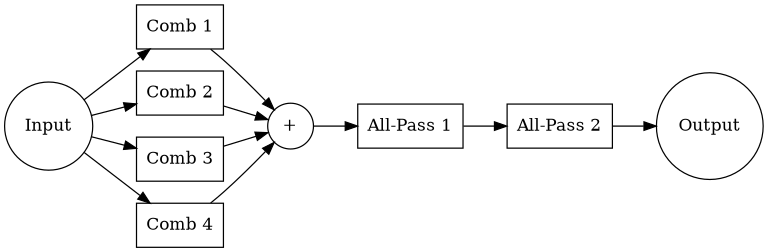

In [72]:


# Create the diagram
dot = Digraph(format='png')
dot.attr(rankdir='LR', size='8')

# Nodes
dot.node('In', 'Input', shape='circle')

for i in range(1, 5):
    dot.node(f'C{i}', f'Comb {i}', shape='box')

dot.node('Sum', '+', shape='circle')
dot.node('AP1', 'All-Pass 1', shape='box')
dot.node('AP2', 'All-Pass 2', shape='box')
dot.node('Out', 'Output', shape='circle')

# Edges
dot.edge('In', 'C1')
dot.edge('In', 'C2')
dot.edge('In', 'C3')
dot.edge('In', 'C4')

dot.edge('C1', 'Sum')
dot.edge('C2', 'Sum')
dot.edge('C3', 'Sum')
dot.edge('C4', 'Sum')

dot.edge('Sum', 'AP1')
dot.edge('AP1', 'AP2')
dot.edge('AP2', 'Out')

# Render to file and display
Image(filename=filename)




The Schroeder reverb above is composed of:

- **Four parallel comb filters**, emulating the **early reflections**.
- **Two serial all-pass filters** to create the **diffuse reverberation**.


In [73]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio






-----

## The Allpass

The allpass filters $A$ in this Schroeder algorithm are defined as:

$$
A = \frac{-g + z^{-N}}{1 - g z^{-N}}
$$

- $N$ is the delay length in samples.
- $g$ are the coefficients.

-----

## The Comb

$$
C = \frac{1}{1 - g z^{-N}}
$$

- $N$ is the delay length in samples.
- $g$ are the coefficients.


---

See: [Julius Smith's Schroeder explanation](https://ccrma.stanford.edu/~jos/pasp/Schroeder_Reverberators.html)

In [74]:
def comb_filter(x, delay_samples, g):
    y = np.zeros_like(x)
    for n in range(delay_samples, len(x)):
        y[n] = x[n] + g * y[n - delay_samples]
    return y

def allpass_filter(x, delay_samples, g):
    y = np.zeros_like(x)
    for n in range(delay_samples, len(x)):
        y[n] = g * (x[n] - y[n - delay_samples]) + x[n - delay_samples]
    return y


In [75]:
def schroeder_reverb(x, fs=48000):
    # Parallel comb filters
    comb_delays = [0.0297, 0.0371, 0.0411, 0.0437]  # in seconds
    g_comb      = 0.805
    combs       = []
    
    for d in comb_delays:
        delay = int(d * fs)
        combs.append(comb_filter(x, delay, g_comb))
    comb_sum = sum(combs) / len(combs)

    # Serial all-pass filters
    apf1 = allpass_filter(comb_sum, int(0.005 * fs), 0.7)
    apf2 = allpass_filter(apf1, int(0.0017 * fs), 0.7)

    return apf2


----

# The Impulse Response

The following impulse response has been created with these parameter settings:

## Allpass

- $g=0.805$
- Delays = $0.0297, 0.0371, 0.0411, 0.0437$ (seconds)

## Combs

- $g_1=0.7$
- Delay 1: $0.005$ (seconds)
- $g_2=0.7$
- Delay 2: $0.0017$ (seconds)



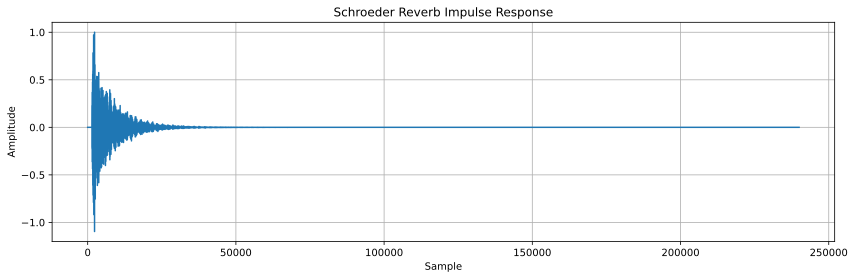

Impulse Response of Schroeder Reverb:


In [76]:
# Impulse signal
fs = 48000  # Sampling rate
duration = 5
n_samples = int(fs * duration)

impulse = np.zeros(n_samples)
impulse[0:2000] = np.random.rand(2000)-0.5

reverb_ir = schroeder_reverb(impulse, fs)

reverb_ir = reverb_ir/(max(reverb_ir))

plt.figure(figsize=(12, 4))
plt.plot(reverb_ir)
plt.title("Schroeder Reverb Impulse Response")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid()
plt.tight_layout()
plt.show()

print("Impulse Response of Schroeder Reverb:")
display(Audio(reverb_ir, rate=fs))

## Sound Example

The following example shows how a violin sound (recorded in an anechoic chamber) sounds with the Schroeder reverb.
Although it is still very artificial, it does a good job at emulating the reverb of a a medium sized room:


Dry Violin Recording:


Violin with Schroeder Reverb:


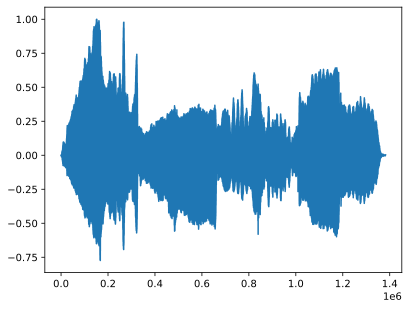

In [78]:
# Dry sine tone


import urllib.request
from scipy.io import wavfile
import io


dry_url = "https://ringbuffer.org/download/audio/violin/Solo_DPA_02.wav"
response = urllib.request.urlopen(dry_url)
audio_data = response.read()
        
with io.BytesIO(audio_data) as temp_file:        
    fs, dry = wavfile.read(temp_file)


# Normalize
dry = dry / np.max(np.abs(dry))
#dry = dry / np.max(np.abs(dry))

 
# Apply reverb
wet = schroeder_reverb(dry, fs)
wet /= np.max(np.abs(wet))  # normalize

# Play both
print("Dry Violin Recording:")
display(Audio(dry, rate=fs))
print("Violin with Schroeder Reverb:")
display(Audio(wet, rate=fs))

plt.plot(dry)

plt.show()


---

# Exercise
 
- 1: Implement a Schroeder reverb with the signal flow shown above.
- 2: Download a solo: https://ringbuffer.org/download/audio/solo_instruments/
- 3: Apply the reverb and explore different parameter settings 


----

## Further reading

- Jot, J.M. (1997). *Efficient Models for Reverberation and Distance Rendering in Computer Music and Virtual Audio Reality*
- Dattorro, J. (2000). *Effect Design: Part 1: Reverberator and Other Filters*
